# Prediccion de Animalitos - Modelo Completo

Este notebook implementa modelos de Machine Learning para predecir el resultado de la loteria de animalitos.

Utilizaremos las tecnicas aprendidas en las semanas 1-7:
- Manipulacion de datos con pandas (Semana 2)
- Ingenieria de caracteristicas (Semanas 4-5)
- Random Forest (Semana 6)
- Redes Neuronales (Semana 7)
- Visualizacion de datos (Semanas 1 y 3)

## Objetivo
Predecir el animalito que saldra en los proximos sorteos basandonos en patrones historicos.

## ADVERTENCIA IMPORTANTE
Este proyecto es EDUCATIVO. Las loterias son aleatorias y ningun modelo puede predecir resultados futuros con certeza.

## 1. Importar Librerias

Importamos todas las herramientas necesarias para el analisis.

In [5]:
# Librerias basicas para manejo de datos (Semana 2)
import pandas as pd
import numpy as np
import os
from datetime import timedelta

# Librerias para visualizacion (Semana 1 y 3)
import matplotlib.pyplot as plt
import seaborn as sns

# Librerias para Random Forest (Semana 6)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Librerias para Redes Neuronales (Semana 7)
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Intentar importar Keras/TensorFlow
try:
    from tensorflow import keras
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    KERAS_AVAILABLE = True
    print("TensorFlow/Keras: Disponible")
except ImportError:
    KERAS_AVAILABLE = False
    print("TensorFlow/Keras: No disponible (solo se usara Random Forest)")

# Configuracion de visualizacion
plt.style.use('ggplot')
sns.set_palette("husl")

# Ignorar advertencias menores para salida mas limpia
import warnings
warnings.filterwarnings('ignore')

print("\nLibrerias importadas exitosamente")

TensorFlow/Keras: Disponible

Librerias importadas exitosamente


## 2. Diccionario de Animalitos

Definimos el mapeo oficial entre cada animalito y su numero.

Este diccionario es fundamental porque:
- Convierte nombres de texto a numeros (que los modelos pueden procesar)
- Homologa los datos del archivo TXT
- Permite la conversion inversa: numero → nombre

In [ ]:
# Diccionario que mapea el nombre del animal con su numero
# Cada animalito tiene un numero asignado del 0 al 75
# Este es el mapeo oficial de la loteria de animalitos

mapa_animales = {
    "Delfín": 0, "Ballena": 0, "Carnero": 1, "Toro": 2, "Ciempiés": 3, "Alacrán": 4,
    "León": 5, "Rana": 6, "Perico": 7, "Ratón": 8, "Águila": 9, "Tigre": 10, 
    "Gato": 11, "Caballo": 12, "Mono": 13, "Paloma": 14, "Zorro": 15, "Oso": 16, 
    "Pavo": 17, "Burro": 18, "Chivo": 19, "Cochino": 20, "Gallo": 21, "Camello": 22, 
    "Cebra": 23, "Iguana": 24, "Gallina": 25, "Vaca": 26, "Perro": 27, "Zamuro": 28, 
    "Elefante": 29, "Caimán": 30, "Lapa": 31, "Ardilla": 32, "Pescado": 33, 
    "Venado": 34, "Jirafa": 35, "Culebra": 36, "Tortuga": 37, "Búfalo": 38, 
    "Lechuza": 39, "Avispa": 40, "Canguro": 41, "Tucán": 42, "Mariposa": 43, 
    "Chigüire": 44, "Garza": 45, "Puma": 46, "Pavo Real": 47, "Puercoespín": 48, 
    "Pereza": 49, "Canario": 50, "Pelícano": 51, "Pulpo": 52, "Caracol": 53, 
    "Grillo": 54, "Oso Hormiguero": 55, "Tiburón": 56, "Pato": 57, "Hormiga": 58, 
    "Pantera": 59, "Camaleón": 60, "Panda": 61, "Cachicamo": 62, "Cangrejo": 63, 
    "Gavilán": 64, "Araña": 65, "Lobo": 66, "Avestruz": 67, "Jaguar": 68, 
    "Conejo": 69, "Bisonte": 70, "Guacamaya": 71, "Gorila": 72, "Hipopótamo": 73, 
    "Turpial": 74, "Guácharo": 75
}

# FUNCION DE NORMALIZACION DE ACENTOS
# Esta funcion elimina acentos para hacer matching flexible
# Ejemplo: "Ratón" -> "Raton", "Caimán" -> "Caiman"

import unicodedata

def normalizar_texto(texto):
    """
    Elimina acentos y tildes de un texto.
    
    Parametros:
        texto (str): Texto con posibles acentos
    
    Retorna:
        str: Texto sin acentos
    """
    # NFD descompone caracteres acentuados: á -> a + ´
    texto_nfd = unicodedata.normalize('NFD', texto)
    
    # Filtra solo caracteres que NO son marcas diacriticas (acentos)
    texto_sin_acentos = ''.join(
        char for char in texto_nfd 
        if unicodedata.category(char) != 'Mn'  # Mn = Marca no espaciadora (acentos)
    )
    
    return texto_sin_acentos

# Crear diccionario NORMALIZADO (sin acentos) para matching
# Esto permite buscar "Raton" y encontrar "Ratón"
mapa_animales_normalizado = {
    normalizar_texto(nombre): numero 
    for nombre, numero in mapa_animales.items()
}

print(f"Diccionario original: {len(mapa_animales)} animalitos")
print(f"Diccionario normalizado: {len(mapa_animales_normalizado)} animalitos")

print("\nEjemplos de normalizacion:")
ejemplos = [("Ratón", 8), ("Caimán", 30), ("Delfín", 0), ("León", 5), ("Águila", 9)]
for nombre, num in ejemplos:
    normalizado = normalizar_texto(nombre)
    print(f"  {nombre:15} -> {normalizado:15} = {num}")

print("\nNota: El diccionario normalizado permite buscar SIN acentos")
print("Ejemplo: 'Raton' (sin acento) encontrara 'Ratón' (con acento)")

Diccionario original: 77 animalitos
Diccionario normalizado: 77 animalitos

Ejemplos de normalizacion:
  Ratón           -> Raton           = 8
  Caimán          -> Caiman          = 30
  Delfín          -> Delfin          = 0
  León            -> Leon            = 5
  Águila          -> Aguila          = 9

Nota: El diccionario normalizado permite buscar SIN acentos
Ejemplo: 'Raton' (sin acento) encontrara 'Ratón' (con acento)


## 3. Cargar y Procesar Datos desde TXT

Procesamos el archivo de texto original usando el diccionario para convertir nombres de animalitos a numeros.

Este proceso muestra como transformar datos en texto plano a un formato estructurado para Machine Learning.

In [14]:
# Nombre del archivo TXT a procesar
archivo_txt = "resultados_guacharoactivo_2024.txt"

# Verificar que el archivo existe
if not os.path.exists(archivo_txt):
    raise FileNotFoundError(
        f"ERROR: No se encuentra el archivo '{archivo_txt}'\n"
        f"Asegurate de tener el archivo en el mismo directorio del notebook.\n"
        f"Directorio actual: {os.getcwd()}"
    )

print(f"Procesando datos desde: {archivo_txt}")
print("="*60)

# PASO 1: Leer el archivo TXT linea por linea (Semana 1)
# Usamos encoding="utf-8" para manejar caracteres especiales como acentos
with open(archivo_txt, "r", encoding="utf-8") as archivo:
    lineas = archivo.readlines()

print(f"Lineas leidas del archivo: {len(lineas)}")

# PASO 2: Procesar cada linea para extraer: Fecha, Hora, Animalito
datos = []
lineas_sin_procesar = []
animalitos_encontrados = set()  # Para estadisticas

for i, linea in enumerate(lineas):
    # Saltar lineas vacias
    if not linea.strip():
        continue
    
    # Formato esperado: "Fecha, Hora, Animalito"
    # Ejemplo: "2024-01-02, 08:00 AM, Ballena"
    partes = linea.strip().split(",")
    
    # Verificar que la linea tiene 3 campos
    if len(partes) == 3:
        fecha = partes[0].strip()      # Eliminar espacios
        hora = partes[1].strip()       # Eliminar espacios
        animalito = partes[2].strip()  # Eliminar espacios
        
        # PASO 3: Normalizar el nombre del animalito (eliminar acentos)
        # Esto permite que "Raton" coincida con "Ratón"
        animalito_normalizado = normalizar_texto(animalito)
        
        # PASO 4: Buscar el numero en el diccionario normalizado
        # Primero intentamos con el nombre normalizado (sin acentos)
        numero = mapa_animales_normalizado.get(animalito_normalizado, None)
        
        # PASO 5: Agregar los datos
        if numero is not None:
            # Guardamos el animalito SIN normalizar (preservamos original)
            datos.append([fecha, hora, animalito, numero])
            animalitos_encontrados.add(animalito)
        else:
            # Guardar lineas con animalitos no reconocidos
            lineas_sin_procesar.append((i+1, animalito, animalito_normalizado))
    else:
        # Guardar lineas con formato incorrecto
        lineas_sin_procesar.append((i+1, linea.strip()[:50], "formato_incorrecto"))

# PASO 6: Crear DataFrame con los datos procesados (Semana 2)
# DataFrame es una tabla de pandas con filas y columnas
df = pd.DataFrame(datos, columns=["Fecha", "Hora", "Animalito", "Número"])

print(f"\nRegistros procesados exitosamente: {len(df):,}")
print(f"Animalitos unicos encontrados: {len(animalitos_encontrados)}")

# ESTADISTICAS DE PROCESAMIENTO
print("\n" + "="*60)
print("ESTADISTICAS DE PROCESAMIENTO")
print("="*60)

tasa_exito = (len(df) / len(lineas)) * 100 if len(lineas) > 0 else 0
print(f"Lineas totales en archivo: {len(lineas):,}")
print(f"Registros procesados: {len(df):,}")
print(f"Tasa de exito: {tasa_exito:.2f}%")

# Mostrar advertencias si hubo lineas no procesadas
if lineas_sin_procesar:
    print(f"\nAdvertencia: {len(lineas_sin_procesar)} lineas NO se procesaron")
    print("Esto puede deberse a:")
    print("  - Animalitos no encontrados en el diccionario")
    print("  - Formato de linea incorrecto (no tiene 3 campos)")
    
    # Mostrar maximo 10 ejemplos
    cantidad_mostrar = min(10, len(lineas_sin_procesar))
    print(f"\nPrimeras {cantidad_mostrar} lineas no procesadas:")
    for num_linea, contenido, normalizado in lineas_sin_procesar[:cantidad_mostrar]:
        if normalizado == "formato_incorrecto":
            print(f"  Linea {num_linea}: Formato incorrecto -> {contenido}")
        else:
            print(f"  Linea {num_linea}: '{contenido}' (normalizado: '{normalizado}') NO encontrado")
else:
    print("\nExcelente: Todas las lineas se procesaron correctamente")

# PASO 7: Guardar DataFrame a CSV para uso futuro (opcional)
# Esto permite cargar mas rapido en proximas ejecuciones
archivo_csv = "resultados_guacharoactivo_completo.csv"
df.to_csv(archivo_csv, index=False, encoding="utf-8")
print(f"\nDatos tambien guardados en: {archivo_csv}")
print("(Puedes usar este CSV para cargar mas rapido en el futuro)")

print("="*60)
print("\nProcesamiento completado exitosamente")

Procesando datos desde: resultados_guacharoactivo_2024.txt
Lineas leidas del archivo: 17304

Registros procesados exitosamente: 17,304
Animalitos unicos encontrados: 77

ESTADISTICAS DE PROCESAMIENTO
Lineas totales en archivo: 17,304
Registros procesados: 17,304
Tasa de exito: 100.00%

Excelente: Todas las lineas se procesaron correctamente

Datos tambien guardados en: resultados_guacharoactivo_completo.csv
(Puedes usar este CSV para cargar mas rapido en el futuro)

Procesamiento completado exitosamente


## 4. Exploracion Inicial de Datos

Verificamos la estructura y calidad de los datos cargados.

In [17]:
# Mostrar primeras filas
print("Primeras 5 filas del dataset:")
print(df.head())

print("\nUltimas 5 filas del dataset:")
print(df.tail())

print("\nInformacion del dataset:")
print(df.info())

print("\nEstadisticas descriptivas (columna numerica):")
print(df['Número'].describe())

# Verificar columnas necesarias
columnas_esperadas = ["Fecha", "Hora", "Animalito", "Número"]
columnas_presentes = df.columns.tolist()

print(f"\nColumnas en el dataset: {columnas_presentes}")

if all(col in columnas_presentes for col in columnas_esperadas):
    print("Todas las columnas necesarias estan presentes")
else:
    faltantes = set(columnas_esperadas) - set(columnas_presentes)
    print(f"ADVERTENCIA: Faltan columnas: {faltantes}")

Primeras 5 filas del dataset:
        Fecha      Hora Animalito  Número
0  2024-01-02  08:00 AM   Ballena       0
1  2024-01-03  08:00 AM   Pescado      33
2  2024-01-04  08:00 AM   Gallina      25
3  2024-01-05  08:00 AM      Lapa      31
4  2024-01-06  08:00 AM     Panda      61

Ultimas 5 filas del dataset:
            Fecha      Hora Animalito  Número
17299  2024-12-31  07:00 PM    Aguila       9
17300  2025-01-02  07:00 PM      Lapa      31
17301  2025-01-03  07:00 PM   Bisonte      70
17302  2025-01-04  07:00 PM   Tortuga      37
17303  2025-01-05  07:00 PM   Canario      50

Informacion del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17304 entries, 0 to 17303
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Fecha      17304 non-null  object
 1   Hora       17304 non-null  object
 2   Animalito  17304 non-null  object
 3   Número     17304 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 54

## 5. Preprocesamiento de Datos

Transformamos fecha y hora a formatos que los modelos puedan usar.

In [19]:
# Limpiar espacios en blanco en la columna Hora
# Ejemplo: " 08:00 AM " → "08:00 AM"
df['Hora'] = df['Hora'].str.strip()

# Convertir la columna Fecha de texto a tipo datetime
# Esto permite extraer caracteristicas como dia, mes, año
# Formato esperado: YYYY-MM-DD (2024-01-02)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m-%d')

# Convertir la columna Hora de formato 12h (AM/PM) a numero de 0-23
# Ejemplo: "08:00 AM" → 8, "02:00 PM" → 14
df['Hora_numerica'] = pd.to_datetime(df['Hora'], format='%I:%M %p').dt.hour

print("Datos preprocesados:")
print(df.head())

# Verificar si hay valores nulos (Semana 5 - Calidad de datos)
print("\nValores nulos por columna:")
print(df.isnull().sum())

if df.isnull().sum().sum() > 0:
    print("\nADVERTENCIA: Hay valores nulos en los datos")
else:
    print("\nNo hay valores nulos. Datos limpios")

Datos preprocesados:
       Fecha      Hora Animalito  Número  Hora_numerica
0 2024-01-02  08:00 AM   Ballena       0              8
1 2024-01-03  08:00 AM   Pescado      33              8
2 2024-01-04  08:00 AM   Gallina      25              8
3 2024-01-05  08:00 AM      Lapa      31              8
4 2024-01-06  08:00 AM     Panda      61              8

Valores nulos por columna:
Fecha            0
Hora             0
Animalito        0
Número           0
Hora_numerica    0
dtype: int64

No hay valores nulos. Datos limpios


## 6. Analisis Exploratorio de Datos (EDA)

Exploramos patrones en los datos historicos mediante estadisticas y visualizaciones.

In [20]:
# Estadisticas basicas
print("="*60)
print("ESTADISTICAS DEL DATASET")
print("="*60)

print(f"Total de sorteos registrados: {len(df):,}")
print(f"\nFecha inicial: {df['Fecha'].min().strftime('%Y-%m-%d')}")
print(f"Fecha final: {df['Fecha'].max().strftime('%Y-%m-%d')}")
print(f"Periodo total: {(df['Fecha'].max() - df['Fecha'].min()).days} dias")

print(f"\nCantidad de animalitos diferentes: {df['Animalito'].nunique()}")
print(f"Cantidad de numeros diferentes: {df['Número'].nunique()}")

print("\nDistribucion de sorteos por hora:")
horas_dist = df['Hora_numerica'].value_counts().sort_index()
for hora, cantidad in horas_dist.items():
    print(f"  {hora:02d}:00 → {cantidad:,} sorteos")

print("="*60)

ESTADISTICAS DEL DATASET
Total de sorteos registrados: 17,304

Fecha inicial: 2024-01-02
Fecha final: 2025-01-05
Periodo total: 369 dias

Cantidad de animalitos diferentes: 77
Cantidad de numeros diferentes: 76

Distribucion de sorteos por hora:
  08:00 → 1,442 sorteos
  09:00 → 1,442 sorteos
  10:00 → 1,442 sorteos
  11:00 → 1,442 sorteos
  12:00 → 1,442 sorteos
  13:00 → 1,442 sorteos
  14:00 → 1,442 sorteos
  15:00 → 1,442 sorteos
  16:00 → 1,442 sorteos
  17:00 → 1,442 sorteos
  18:00 → 1,442 sorteos
  19:00 → 1,442 sorteos


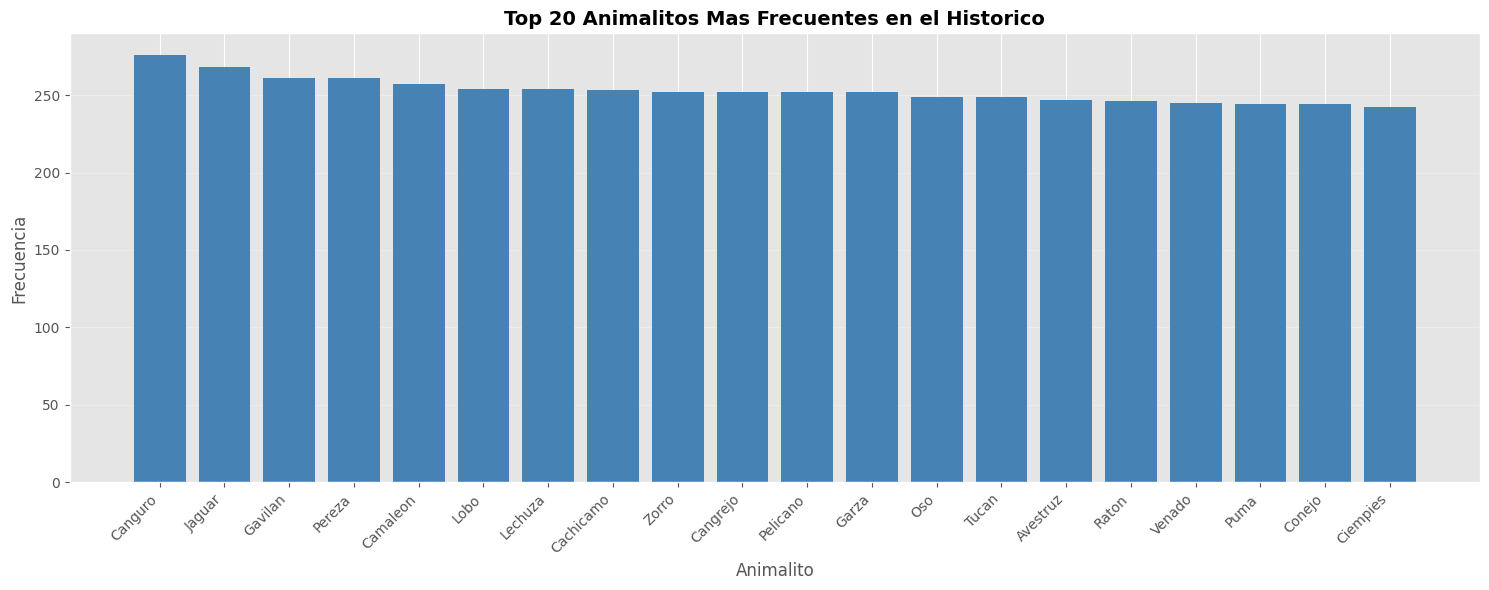


Top 10 animalitos mas frecuentes:
 1. Canguro         → 276 veces (1.60%)
 2. Jaguar          → 268 veces (1.55%)
 3. Gavilan         → 261 veces (1.51%)
 4. Pereza          → 261 veces (1.51%)
 5. Camaleon        → 257 veces (1.49%)
 6. Lobo            → 254 veces (1.47%)
 7. Lechuza         → 254 veces (1.47%)
 8. Cachicamo       → 253 veces (1.46%)
 9. Zorro           → 252 veces (1.46%)
10. Cangrejo        → 252 veces (1.46%)


In [21]:
# Visualizacion: Animalitos mas frecuentes (Semana 3)

plt.figure(figsize=(15, 6))

# Contar frecuencia de cada animalito
top_animales = df['Animalito'].value_counts().head(20)

plt.bar(range(len(top_animales)), top_animales.values, color='steelblue')
plt.xticks(range(len(top_animales)), top_animales.index, rotation=45, ha='right')
plt.xlabel('Animalito', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Top 20 Animalitos Mas Frecuentes en el Historico', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 animalitos mas frecuentes:")
for i, (animal, freq) in enumerate(top_animales.head(10).items(), 1):
    porcentaje = (freq / len(df)) * 100
    print(f"{i:2}. {animal:15} → {freq:,} veces ({porcentaje:.2f}%)")

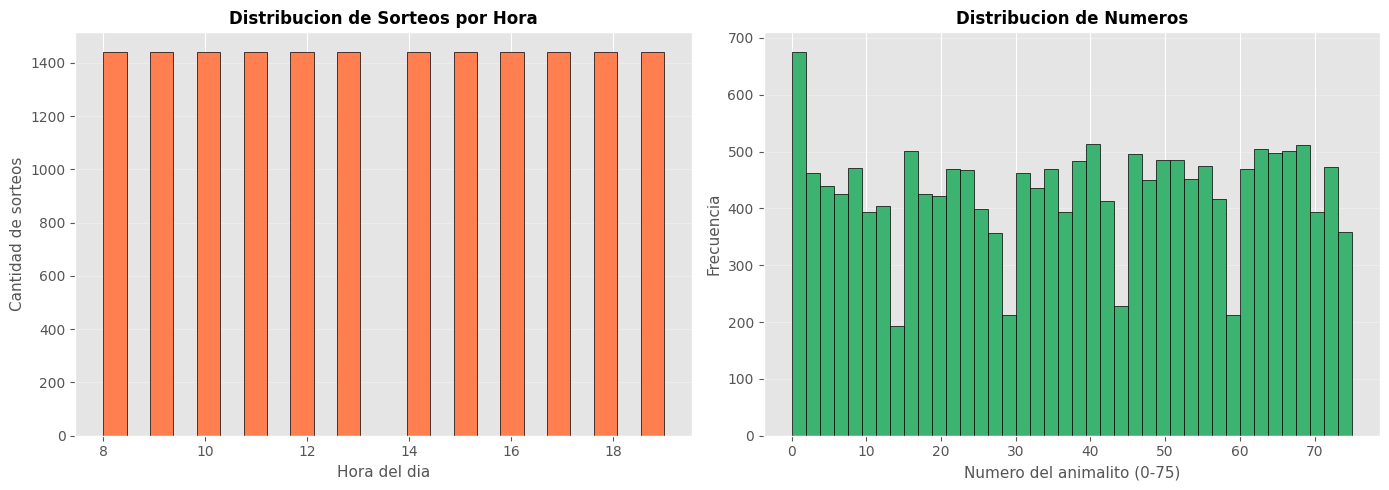

In [22]:
# Visualizacion: Distribucion por hora y numero

plt.figure(figsize=(14, 5))

# Grafico 1: Distribucion por hora
plt.subplot(1, 2, 1)
df['Hora_numerica'].hist(bins=24, edgecolor='black', color='coral')
plt.xlabel('Hora del dia', fontsize=11)
plt.ylabel('Cantidad de sorteos', fontsize=11)
plt.title('Distribucion de Sorteos por Hora', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Grafico 2: Distribucion de numeros
plt.subplot(1, 2, 2)
df['Número'].hist(bins=40, edgecolor='black', color='mediumseagreen')
plt.xlabel('Numero del animalito (0-75)', fontsize=11)
plt.ylabel('Frecuencia', fontsize=11)
plt.title('Distribucion de Numeros', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Ingenieria de Caracteristicas (Feature Engineering)

Creamos nuevas variables que ayuden al modelo a detectar patrones.

**Caracteristicas temporales**: capturan ciclos (dia/semana/mes)
**Caracteristicas de secuencia**: capturan "memoria" del sistema
**Caracteristicas derivadas**: combinan informacion existente

In [23]:
# Crear copia para no modificar el original
df_features = df.copy()

print("Creando caracteristicas temporales...")

# CARACTERISTICAS TEMPORALES (extraidas de la fecha)

# Dia de la semana: 0=Lunes, 1=Martes, ..., 6=Domingo
df_features['Dia_semana'] = df_features['Fecha'].dt.dayofweek

# Dia del mes: 1 a 31
df_features['Dia_mes'] = df_features['Fecha'].dt.day

# Mes del año: 1=Enero, 2=Febrero, ..., 12=Diciembre
df_features['Mes'] = df_features['Fecha'].dt.month

# Año
df_features['Año'] = df_features['Fecha'].dt.year

# Dias transcurridos desde el primer sorteo
# Captura tendencia temporal global
df_features['Dias_desde_inicio'] = (df_features['Fecha'] - df_features['Fecha'].min()).dt.days

print("Creando caracteristicas de secuencia...")

# Ordenar por fecha y hora para mantener secuencia correcta
df_features = df_features.sort_values(['Fecha', 'Hora_numerica']).reset_index(drop=True)

# CARACTERISTICAS DE SECUENCIA (resultados anteriores)

# Numero que salio en el sorteo inmediatamente anterior
df_features['Numero_anterior_1'] = df_features['Número'].shift(1)

# Numero que salio hace 2 sorteos
df_features['Numero_anterior_2'] = df_features['Número'].shift(2)

# Numero que salio hace 3 sorteos
df_features['Numero_anterior_3'] = df_features['Número'].shift(3)

print("Creando caracteristicas derivadas...")

# CARACTERISTICAS DERIVADAS

# Promedio movil de los ultimos 5 resultados
# Suaviza fluctuaciones y captura tendencia reciente
df_features['Promedio_ultimos_5'] = df_features['Número'].rolling(
    window=5, 
    min_periods=1
).mean()

# Periodo del dia (agrupacion de horas)
# Reduce complejidad de 24 horas a 4 periodos
def clasificar_periodo(hora):
    if 6 <= hora < 12:
        return 0  # Mañana (6 AM - 11 AM)
    elif 12 <= hora < 18:
        return 1  # Tarde (12 PM - 5 PM)
    elif 18 <= hora < 24:
        return 2  # Noche (6 PM - 11 PM)
    else:
        return 3  # Madrugada (12 AM - 5 AM)

df_features['Periodo_dia'] = df_features['Hora_numerica'].apply(clasificar_periodo)

# Eliminar filas con valores NaN generados por shift()
# Los primeros 3 registros no tienen "resultados anteriores"
filas_antes = len(df_features)
df_features = df_features.dropna()
filas_despues = len(df_features)

print(f"\nCaracteristicas creadas exitosamente")
print(f"Filas eliminadas (sin historial): {filas_antes - filas_despues}")
print(f"Filas finales: {filas_despues:,}")

print("\nLista completa de caracteristicas:")
for i, col in enumerate(df_features.columns, 1):
    print(f"  {i:2}. {col}")

print("\nPrimeras filas con nuevas caracteristicas:")
print(df_features.head(10))

Creando caracteristicas temporales...
Creando caracteristicas de secuencia...
Creando caracteristicas derivadas...

Caracteristicas creadas exitosamente
Filas eliminadas (sin historial): 3
Filas finales: 17,301

Lista completa de caracteristicas:
   1. Fecha
   2. Hora
   3. Animalito
   4. Número
   5. Hora_numerica
   6. Dia_semana
   7. Dia_mes
   8. Mes
   9. Año
  10. Dias_desde_inicio
  11. Numero_anterior_1
  12. Numero_anterior_2
  13. Numero_anterior_3
  14. Promedio_ultimos_5
  15. Periodo_dia

Primeras filas con nuevas caracteristicas:
        Fecha      Hora Animalito  Número  Hora_numerica  Dia_semana  Dia_mes  \
3  2024-01-02  08:00 AM   Ballena       0              8           1        2   
4  2024-01-02  09:00 AM   Caballo      12              9           1        2   
5  2024-01-02  09:00 AM   Caballo      12              9           1        2   
6  2024-01-02  09:00 AM   Caballo      12              9           1        2   
7  2024-01-02  09:00 AM   Caballo      12 

## 8. Preparacion de Datos para Modelado

Separamos las caracteristicas (X) de la variable objetivo (y) y dividimos en entrenamiento/prueba.

In [24]:
# Definir las caracteristicas que usaremos para predecir (X)
# Estas son las variables independientes (features)
feature_columns = [
    'Hora_numerica',           # Hora del sorteo (0-23)
    'Dia_semana',              # Dia de la semana (0-6)
    'Dia_mes',                 # Dia del mes (1-31)
    'Mes',                     # Mes del año (1-12)
    'Dias_desde_inicio',       # Tendencia temporal
    'Numero_anterior_1',       # Resultado del sorteo anterior
    'Numero_anterior_2',       # Resultado hace 2 sorteos
    'Numero_anterior_3',       # Resultado hace 3 sorteos
    'Promedio_ultimos_5',      # Promedio movil reciente
    'Periodo_dia'              # Periodo del dia (0-3)
]

# X: matriz de caracteristicas (variables independientes)
X = df_features[feature_columns]

# y: vector objetivo (variable dependiente - lo que queremos predecir)
y = df_features['Animalito']

print("Datos preparados para modelado:")
print(f"  X (caracteristicas): {X.shape[0]:,} filas x {X.shape[1]} columnas")
print(f"  y (objetivo): {y.shape[0]:,} valores")
print(f"  Clases diferentes (animalitos): {y.nunique()}")

print("\nEjemplo de datos X (primeras 3 filas):")
print(X.head(3))

print("\nEjemplo de datos y (primeras 10 valores):")
print(y.head(10).tolist())

Datos preparados para modelado:
  X (caracteristicas): 17,301 filas x 10 columnas
  y (objetivo): 17,301 valores
  Clases diferentes (animalitos): 77

Ejemplo de datos X (primeras 3 filas):
   Hora_numerica  Dia_semana  Dia_mes  Mes  Dias_desde_inicio  \
3              8           1        2    1                  0   
4              9           1        2    1                  0   
5              9           1        2    1                  0   

   Numero_anterior_1  Numero_anterior_2  Numero_anterior_3  \
3                0.0                0.0                0.0   
4                0.0                0.0                0.0   
5               12.0                0.0                0.0   

   Promedio_ultimos_5  Periodo_dia  
3                 0.0            0  
4                 2.4            0  
5                 4.8            0  

Ejemplo de datos y (primeras 10 valores):
['Ballena', 'Caballo', 'Caballo', 'Caballo', 'Caballo', 'Gallina', 'Gallina', 'Gallina', 'Gallina', 'Avispa']

In [25]:
# Dividir los datos en conjunto de entrenamiento y prueba (Semana 4)
# 80% para entrenar el modelo
# 20% para evaluar el modelo (datos que nunca vio)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% para prueba
    random_state=42,      # Semilla para reproducibilidad
    stratify=y            # Mantener proporcion de clases en ambos conjuntos
)

print("="*60)
print("DIVISION DE DATOS")
print("="*60)

print(f"Datos de ENTRENAMIENTO: {X_train.shape[0]:,} registros ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Datos de PRUEBA: {X_test.shape[0]:,} registros ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nCaracteristicas por registro: {X_train.shape[1]}")
print(f"Clases en entrenamiento: {y_train.nunique()}")
print(f"Clases en prueba: {y_test.nunique()}")

print("="*60)

DIVISION DE DATOS
Datos de ENTRENAMIENTO: 13,840 registros (80.0%)
Datos de PRUEBA: 3,461 registros (20.0%)

Caracteristicas por registro: 10
Clases en entrenamiento: 77
Clases en prueba: 77


## 9. Modelo 1: Random Forest

Random Forest combina multiples arboles de decision para hacer predicciones.

**Como funciona**:
1. Crea multiples arboles de decision (200 en nuestro caso)
2. Cada arbol se entrena con una muestra aleatoria de datos
3. Para predecir, cada arbol vota
4. La clase mas votada es la prediccion final

**Ventajas**:
- Resistente al sobreajuste
- Maneja bien datos no lineales
- Proporciona importancia de caracteristicas

In [26]:
# Crear el modelo Random Forest con parametros optimizados

rf_model = RandomForestClassifier(
    n_estimators=200,        # Cantidad de arboles en el bosque
    max_depth=20,            # Profundidad maxima de cada arbol
    min_samples_split=10,    # Minimo de muestras para dividir un nodo
    min_samples_leaf=5,      # Minimo de muestras en hoja
    random_state=42,         # Semilla para reproducibilidad
    n_jobs=-1,               # Usar todos los CPUs disponibles
    verbose=1                # Mostrar progreso durante entrenamiento
)

print("Parametros del modelo Random Forest:")
print(f"  Arboles: {rf_model.n_estimators}")
print(f"  Profundidad maxima: {rf_model.max_depth}")
print(f"  Min muestras para dividir: {rf_model.min_samples_split}")
print(f"  Min muestras en hoja: {rf_model.min_samples_leaf}")

print("\nEntrenando Random Forest...")
print("Esto puede tardar algunos segundos...")

# Entrenar el modelo con datos de entrenamiento
rf_model.fit(X_train, y_train)

print("\nEntrenamiento completado")

Parametros del modelo Random Forest:
  Arboles: 200
  Profundidad maxima: 20
  Min muestras para dividir: 10
  Min muestras en hoja: 5

Entrenando Random Forest...
Esto puede tardar algunos segundos...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.0s



Entrenamiento completado


[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.3s finished


In [27]:
# Evaluar el modelo Random Forest

# Predecir en conjunto de prueba
y_pred_rf = rf_model.predict(X_test)

# Calcular precision: porcentaje de predicciones correctas
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("="*60)
print("EVALUACION RANDOM FOREST")
print("="*60)

print(f"Precision en prueba: {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")

# Precision esperada por azar
precision_azar = 1 / y.nunique()
print(f"Precision por azar: {precision_azar:.4f} ({precision_azar*100:.2f}%)")

mejora = (accuracy_rf / precision_azar) - 1
print(f"Mejora sobre azar: {mejora*100:.1f}%")

print("\nRealizando validacion cruzada (5 particiones)...")
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, n_jobs=-1)

print(f"Puntuaciones CV: {[f'{score:.4f}' for score in cv_scores]}")
print(f"Precision media CV: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

print("="*60)

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.0s finished


EVALUACION RANDOM FOREST
Precision en prueba: 0.6882 (68.82%)
Precision por azar: 0.0130 (1.30%)
Mejora sobre azar: 5199.5%

Realizando validacion cruzada (5 particiones)...
Puntuaciones CV: ['0.6922', '0.7041', '0.7085', '0.7012', '0.7066']
Precision media CV: 0.7025 (+/- 0.0057)


Importancia de caracteristicas (ordenado de mayor a menor):
    Caracteristica  Importancia
 Numero_anterior_1     0.391229
 Numero_anterior_2     0.205187
Promedio_ultimos_5     0.092298
 Numero_anterior_3     0.091236
 Dias_desde_inicio     0.054964
           Dia_mes     0.049271
     Hora_numerica     0.043316
        Dia_semana     0.032249
               Mes     0.028245
       Periodo_dia     0.012005


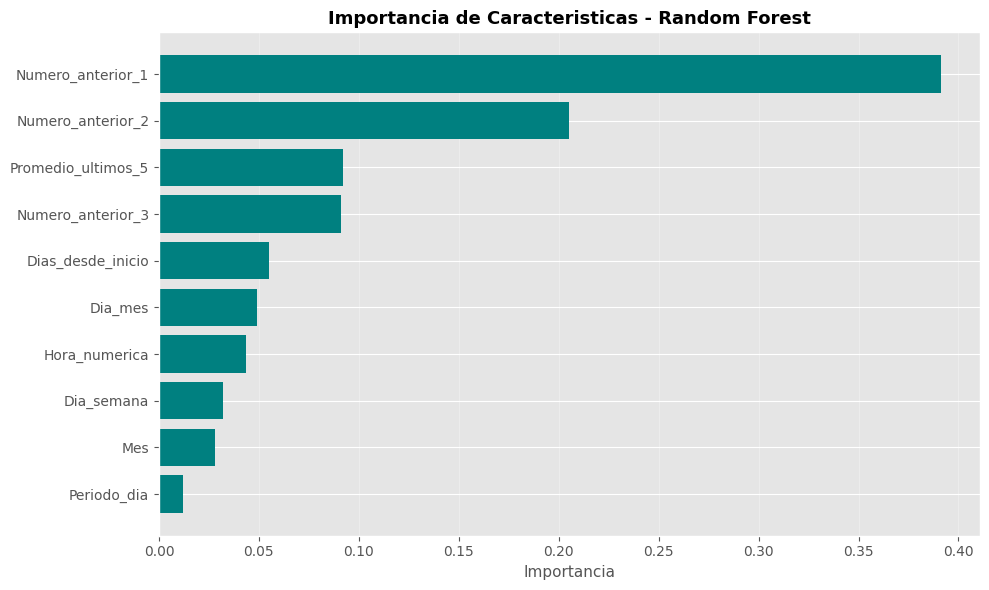


Interpretacion:
La caracteristica mas importante es: Numero_anterior_1
Con importancia de: 0.3912


In [28]:
# Importancia de caracteristicas (Semana 6)
# Indica que caracteristicas son mas utiles para la prediccion

feature_importance = pd.DataFrame({
    'Caracteristica': feature_columns,
    'Importancia': rf_model.feature_importances_
}).sort_values('Importancia', ascending=False)

print("Importancia de caracteristicas (ordenado de mayor a menor):")
print(feature_importance.to_string(index=False))

# Visualizar importancia
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Caracteristica'], feature_importance['Importancia'], color='teal')
plt.xlabel('Importancia', fontsize=11)
plt.title('Importancia de Caracteristicas - Random Forest', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretacion:")
print(f"La caracteristica mas importante es: {feature_importance.iloc[0]['Caracteristica']}")
print(f"Con importancia de: {feature_importance.iloc[0]['Importancia']:.4f}")

## 10. Modelo 2: Red Neuronal

Las redes neuronales aprenden representaciones complejas de los datos.

**Arquitectura**:
- Capa de entrada: recibe las 10 caracteristicas
- Capas ocultas: procesan y transforman la informacion
- Capa de salida: una neurona por cada animalito (76 clases)

**Tecnicas usadas**:
- Normalizacion: escala datos para mejor aprendizaje
- Dropout: evita sobreajuste apagando neuronas aleatoriamente
- Early Stopping: detiene si no mejora

In [29]:
if KERAS_AVAILABLE:
    print("Preparando datos para Red Neuronal...")
    
    # Normalizar caracteristicas (Semana 7)
    # Transforma datos para que tengan media=0 y desviacion=1
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print("Datos normalizados")
    print(f"  Media de X_train_scaled: {X_train_scaled.mean():.6f}")
    print(f"  Desviacion de X_train_scaled: {X_train_scaled.std():.6f}")
    
    # Codificar nombres de animalitos a numeros
    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train)
    y_test_encoded = label_encoder.transform(y_test)
    
    num_classes = len(label_encoder.classes_)
    
    print(f"\nCantidad de clases (animalitos): {num_classes}")
    print(f"Forma de X_train escalado: {X_train_scaled.shape}")
    print(f"Forma de y_train codificado: {y_train_encoded.shape}")
    
else:
    print("Keras no esta disponible. Saltando Red Neuronal.")

Preparando datos para Red Neuronal...
Datos normalizados
  Media de X_train_scaled: -0.000000
  Desviacion de X_train_scaled: 1.000000

Cantidad de clases (animalitos): 77
Forma de X_train escalado: (13840, 10)
Forma de y_train codificado: (13840,)


In [30]:
if KERAS_AVAILABLE:
    print("Construyendo arquitectura de Red Neuronal...\n")
    
    # Crear modelo secuencial (capa por capa)
    nn_model = Sequential([
        # Primera capa oculta: 128 neuronas
        Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dropout(0.3),  # Dropout 30%
        
        # Segunda capa oculta: 64 neuronas
        Dense(64, activation='relu'),
        Dropout(0.3),
        
        # Tercera capa oculta: 32 neuronas
        Dense(32, activation='relu'),
        Dropout(0.2),  # Dropout 20%
        
        # Capa de salida: una neurona por clase
        Dense(num_classes, activation='softmax')
    ])
    
    # Compilar modelo
    nn_model.compile(
        optimizer='adam',                        # Optimizador adaptativo
        loss='sparse_categorical_crossentropy',  # Funcion de perdida
        metrics=['accuracy']                     # Metrica a monitorear
    )
    
    # Mostrar arquitectura
    print("Arquitectura de la Red Neuronal:")
    nn_model.summary()
    
else:
    print("Keras no esta disponible.")

Construyendo arquitectura de Red Neuronal...

Arquitectura de la Red Neuronal:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 77)             │         2,541 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,285 (55.80 KB)

 Trainable params: 14,285 (55.80 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
if KERAS_AVAILABLE:
    # Configurar Early Stopping (Semana 7)
    early_stop = EarlyStopping(
        monitor='val_loss',           # Monitorear perdida en validacion
        patience=10,                  # Esperar 10 epocas sin mejora
        restore_best_weights=True,    # Restaurar mejores pesos al final
        verbose=1
    )
    
    print("Entrenando Red Neuronal...")
    print("Esto puede tardar varios minutos...\n")
    
    # Entrenar el modelo
    history = nn_model.fit(
        X_train_scaled,
        y_train_encoded,
        epochs=100,                   # Maximo 100 epocas
        batch_size=32,                # Procesar 32 muestras a la vez
        validation_split=0.2,         # 20% para validacion durante entrenamiento
        callbacks=[early_stop],       # Usar early stopping
        verbose=1
    )
    
    print("\nEntrenamiento completado")
    print(f"Epocas ejecutadas: {len(history.history['loss'])}")
    
else:
    print("Keras no esta disponible.")

Entrenando Red Neuronal...
Esto puede tardar varios minutos...

Epoch 1/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.0201 - loss: 4.2408 - val_accuracy: 0.0224 - val_loss: 4.0179
Epoch 2/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 882us/step - accuracy: 0.0317 - loss: 4.0065 - val_accuracy: 0.0379 - val_loss: 3.8779
Epoch 3/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 862us/step - accuracy: 0.0410 - loss: 3.8723 - val_accuracy: 0.0455 - val_loss: 3.7283
Epoch 4/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 870us/step - accuracy: 0.0487 - loss: 3.7393 - val_accuracy: 0.0506 - val_loss: 3.6043
Epoch 5/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 870us/step - accuracy: 0.0541 - loss: 3.6410 - val_accuracy: 0.0585 - val_loss: 3.5174
Epoch 6/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 870us/step - accuracy: 0.0609 - loss: 3.5572 - val_accuracy: 0.0618 - val_loss: 3.4350
Epoch 7/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 899us/step - accuracy: 0.0672 - loss: 3.4778 - val_accuracy: 0.0751 - val_loss: 3.3500
Epoch 8/100
346/346 ━

EVALUACION RED NEURONAL
Precision en prueba: 0.2869 (28.69%)
Precision por azar: 0.0130 (1.30%)
Mejora sobre azar: 2109.2%


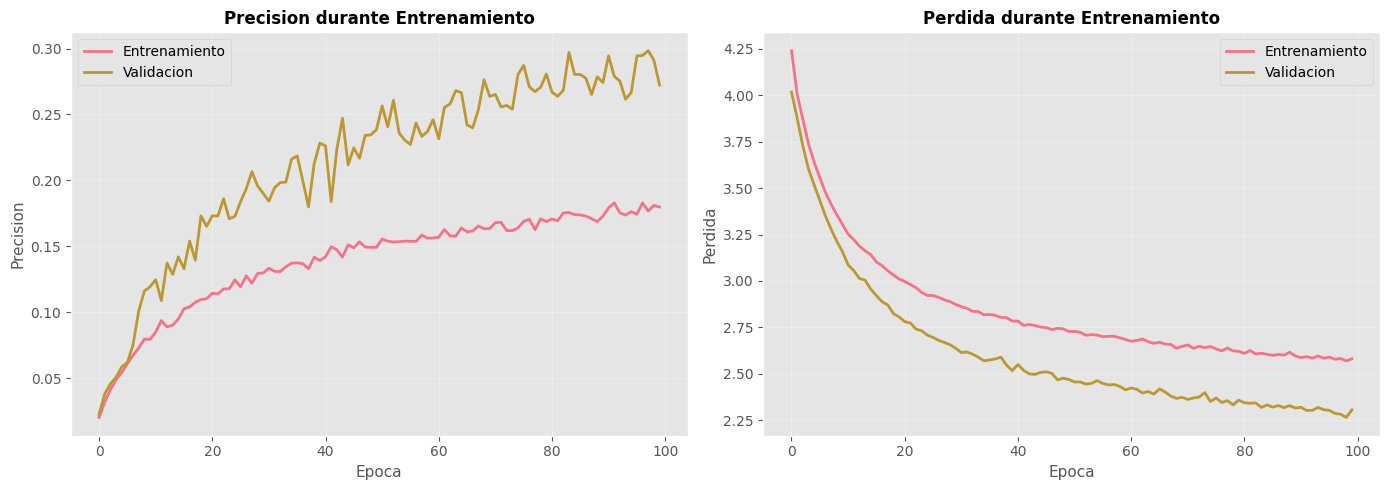

In [32]:
if KERAS_AVAILABLE:
    # Evaluar Red Neuronal
    
    y_pred_nn_prob = nn_model.predict(X_test_scaled, verbose=0)
    y_pred_nn = np.argmax(y_pred_nn_prob, axis=1)
    
    accuracy_nn = accuracy_score(y_test_encoded, y_pred_nn)
    
    print("="*60)
    print("EVALUACION RED NEURONAL")
    print("="*60)
    
    print(f"Precision en prueba: {accuracy_nn:.4f} ({accuracy_nn*100:.2f}%)")
    
    precision_azar = 1 / num_classes
    print(f"Precision por azar: {precision_azar:.4f} ({precision_azar*100:.2f}%)")
    
    mejora_nn = (accuracy_nn / precision_azar) - 1
    print(f"Mejora sobre azar: {mejora_nn*100:.1f}%")
    
    print("="*60)
    
    # Visualizar historial de entrenamiento
    plt.figure(figsize=(14, 5))
    
    # Grafico de precision
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Entrenamiento', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Validacion', linewidth=2)
    plt.xlabel('Epoca', fontsize=11)
    plt.ylabel('Precision', fontsize=11)
    plt.title('Precision durante Entrenamiento', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Grafico de perdida
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Entrenamiento', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validacion', linewidth=2)
    plt.xlabel('Epoca', fontsize=11)
    plt.ylabel('Perdida', fontsize=11)
    plt.title('Perdida durante Entrenamiento', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("Keras no esta disponible.")

## 11. Comparacion de Modelos

Comparamos el desempeño de ambos modelos para elegir el mejor.

In [33]:
# Tabla comparativa

if KERAS_AVAILABLE:
    resultados = pd.DataFrame({
        'Modelo': ['Random Forest', 'Red Neuronal'],
        'Precision': [accuracy_rf, accuracy_nn],
        'Precision (%)': [accuracy_rf*100, accuracy_nn*100]
    })
    
    mejor_modelo_nombre = "Random Forest" if accuracy_rf > accuracy_nn else "Red Neuronal"
    mejor_precision = max(accuracy_rf, accuracy_nn)
    
else:
    resultados = pd.DataFrame({
        'Modelo': ['Random Forest'],
        'Precision': [accuracy_rf],
        'Precision (%)': [accuracy_rf*100]
    })
    
    mejor_modelo_nombre = "Random Forest"
    mejor_precision = accuracy_rf

print("\n" + "="*60)
print("COMPARACION DE MODELOS")
print("="*60)
print(resultados.to_string(index=False))
print("="*60)

print(f"\nMejor modelo: {mejor_modelo_nombre}")
print(f"Precision: {mejor_precision:.4f} ({mejor_precision*100:.2f}%)")

# Interpretacion
if mejor_precision > 0.9:
    print("\nADVERTENCIA: Precision muy alta sugiere posible sobreajuste")
elif mejor_precision > 0.5:
    print("\nEl modelo muestra aprendizaje significativo")
else:
    print("\nEl modelo tiene dificultades para encontrar patrones claros")


COMPARACION DE MODELOS
       Modelo  Precision  Precision (%)
Random Forest   0.688240      68.824039
 Red Neuronal   0.286911      28.691130

Mejor modelo: Random Forest
Precision: 0.6882 (68.82%)

El modelo muestra aprendizaje significativo


## 12. Predicciones para Proximos Sorteos

Usamos el mejor modelo para predecir los sorteos del proximo dia.

In [34]:
# Determinar cual modelo usar
if KERAS_AVAILABLE and accuracy_nn > accuracy_rf:
    modelo_prediccion = 'neural'
    print("Usando Red Neuronal para predicciones")
else:
    modelo_prediccion = 'random_forest'
    print("Usando Random Forest para predicciones")

# Obtener ultima informacion del dataset
ultima_fecha = df_features['Fecha'].max()
ultima_fila = df_features.iloc[-1]

print(f"\nUltima fecha en datos historicos: {ultima_fecha.strftime('%Y-%m-%d')}")
print(f"Ultimo numero registrado: {ultima_fila['Número']}")
print(f"Ultimo animalito: {ultima_fila['Animalito']}")

Usando Random Forest para predicciones

Ultima fecha en datos historicos: 2025-01-05
Ultimo numero registrado: 50
Ultimo animalito: Canario


In [35]:
# Generar predicciones para el proximo dia

proxima_fecha = ultima_fecha + timedelta(days=1)
horas_sorteo = list(range(8, 20))  # De 8 AM a 7 PM (12 sorteos)

print(f"Generando predicciones para: {proxima_fecha.strftime('%Y-%m-%d')}")
print(f"Sorteos a predecir: {len(horas_sorteo)}\n")

predicciones_futuras = []

# Valores iniciales: ultimos resultados conocidos
numero_ant_1 = ultima_fila['Número']
numero_ant_2 = df_features.iloc[-2]['Número']
numero_ant_3 = df_features.iloc[-3]['Número']
promedio_ult_5 = df_features.iloc[-5:]['Número'].mean()

for hora in horas_sorteo:
    # Calcular caracteristicas para este sorteo futuro
    dias_desde_inicio = (proxima_fecha - df_features['Fecha'].min()).days
    
    # Clasificar periodo del dia
    periodo = clasificar_periodo(hora)
    
    # Crear fila con todas las caracteristicas
    nueva_fila = pd.DataFrame([{
        'Hora_numerica': hora,
        'Dia_semana': proxima_fecha.dayofweek,
        'Dia_mes': proxima_fecha.day,
        'Mes': proxima_fecha.month,
        'Dias_desde_inicio': dias_desde_inicio,
        'Numero_anterior_1': numero_ant_1,
        'Numero_anterior_2': numero_ant_2,
        'Numero_anterior_3': numero_ant_3,
        'Promedio_ultimos_5': promedio_ult_5,
        'Periodo_dia': periodo
    }])
    
    # Predecir con el modelo seleccionado
    if modelo_prediccion == 'neural' and KERAS_AVAILABLE:
        nueva_fila_scaled = scaler.transform(nueva_fila)
        pred_prob = nn_model.predict(nueva_fila_scaled, verbose=0)
        pred_encoded = np.argmax(pred_prob)
        animalito_pred = label_encoder.inverse_transform([pred_encoded])[0]
        confianza = np.max(pred_prob)
    else:
        pred = rf_model.predict(nueva_fila)
        pred_prob = rf_model.predict_proba(nueva_fila)
        animalito_pred = pred[0]
        confianza = np.max(pred_prob)
    
    # Obtener numero del animalito predicho usando el diccionario
    numero_pred = mapa_animales[animalito_pred]
    
    # Guardar prediccion
    predicciones_futuras.append({
        'Fecha': proxima_fecha.strftime('%Y-%m-%d'),
        'Hora': f"{hora:02d}:00",
        'Animalito': animalito_pred,
        'Numero': numero_pred,
        'Confianza': f"{confianza*100:.2f}%"
    })
    
    # Actualizar valores para proxima iteracion
    # La prediccion actual se convierte en "resultado anterior" para la siguiente
    numero_ant_3 = numero_ant_2
    numero_ant_2 = numero_ant_1
    numero_ant_1 = numero_pred

# Crear DataFrame con predicciones
df_predicciones = pd.DataFrame(predicciones_futuras)

print(f"{'='*70}")
print(f"PREDICCIONES PARA {proxima_fecha.strftime('%A %Y-%m-%d')}")
print(f"{'='*70}")
print(df_predicciones.to_string(index=False))
print(f"{'='*70}")

Generando predicciones para: 2025-01-06
Sorteos a predecir: 12



[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Do

PREDICCIONES PARA Monday 2025-01-06
     Fecha  Hora Animalito  Numero Confianza
2025-01-06 08:00   Canario      50    14.84%
2025-01-06 09:00   Canario      50    32.76%
2025-01-06 10:00   Canario      50    22.83%
2025-01-06 11:00   Canario      50    23.12%
2025-01-06 12:00   Canario      50    25.38%
2025-01-06 13:00   Canario      50    25.00%
2025-01-06 14:00   Canario      50    24.47%
2025-01-06 15:00   Canario      50    24.28%
2025-01-06 16:00   Canario      50    24.59%
2025-01-06 17:00   Canario      50    23.65%
2025-01-06 18:00   Canario      50    21.40%
2025-01-06 19:00   Canario      50    21.53%


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Do

In [ ]:
# Guardar predicciones a archivo CSV

archivo_predicciones = 'predicciones_proximos_sorteos.csv'
df_predicciones.to_csv(archivo_predicciones, index=False)

print(f"Predicciones guardadas en: {archivo_predicciones}")
print(f"Total de predicciones: {len(df_predicciones)}")

## 13. Analisis de Predicciones

Analizamos los animalitos predichos.

In [ ]:
# Contar frecuencia de animalitos predichos
frecuencia_predicciones = df_predicciones['Animalito'].value_counts()

print("Animalitos predichos y sus frecuencias:")
for animal, freq in frecuencia_predicciones.items():
    porcentaje = (freq / len(df_predicciones)) * 100
    print(f"  {animal:15} → {freq} veces ({porcentaje:.1f}%)")

# Visualizar
plt.figure(figsize=(12, 5))
plt.bar(range(len(frecuencia_predicciones)), frecuencia_predicciones.values, color='darkorange')
plt.xticks(range(len(frecuencia_predicciones)), frecuencia_predicciones.index, rotation=45, ha='right')
plt.xlabel('Animalito', fontsize=11)
plt.ylabel('Frecuencia Predicha', fontsize=11)
plt.title(f'Distribucion de Predicciones para {proxima_fecha.strftime("%Y-%m-%d")}', 
          fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nEl modelo predice {len(frecuencia_predicciones)} animalitos diferentes")
print(f"El animalito mas predicho es: {frecuencia_predicciones.index[0]}")

## 14. Conclusiones y Limitaciones

### Conceptos Aprendidos

En este proyecto aplicamos tecnicas de las semanas 1-7:

1. **Semana 1-2**: Lectura de archivos, manipulacion con pandas
2. **Semana 3**: Visualizacion de datos, analisis exploratorio
3. **Semana 4-5**: Preparacion de datos, division train/test
4. **Semana 6**: Random Forest, validacion cruzada, importancia de caracteristicas
5. **Semana 7**: Redes neuronales, normalizacion, early stopping

### Proceso Completo de Machine Learning

1. Cargar y limpiar datos
2. Analisis exploratorio (EDA)
3. Ingenieria de caracteristicas
4. Entrenamiento de modelos
5. Evaluacion y comparacion
6. Predicciones

### ADVERTENCIAS IMPORTANTES

#### 1. Naturaleza Aleatoria
Las loterias son sistemas ALEATORIOS por diseño. Cada sorteo es independiente del anterior.

#### 2. Sobreajuste
Si la precision es muy alta (>90%), el modelo probablemente esta sobreajustado - memoriza patrones del pasado que no se repetiran.

#### 3. Precision ≠ Exito Futuro
Alta precision en datos historicos NO garantiza predicciones correctas futuras.

#### 4. Uso Etico
- Este proyecto es EDUCATIVO
- NO debe usarse para tomar decisiones financieras
- NO debe usarse para apostar dinero

### Valor Educativo

Este proyecto enseña:
- Flujo completo de Machine Learning
- Uso de librerias profesionales (pandas, sklearn, keras)
- Ingenieria de caracteristicas creativa
- Evaluacion rigurosa de modelos
- Pensamiento critico sobre resultados

### Proximos Pasos

Aplicar estas tecnicas a:
- Prediccion de precios
- Clasificacion de imagenes
- Analisis de sentimientos
- Deteccion de fraudes
- Sistemas de recomendacion

Donde SI existen patrones reales que aprender.